In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("DRIFT DETECTION SYSTEM")
print("="*60)



CUSTOM DRIFT DETECTION SYSTEM


In [13]:
df = pd.read_csv('../data/processed/cleaned_sales.csv', parse_dates=['InvoiceDate'])

# Reference data: First 6 months of 2009
reference = df[df['InvoiceDate'] < '2009-07-01'].copy()

# Current data: Last 3 months of 2009
current = df[df['InvoiceDate'] >= '2009-10-01'].copy()

print(f"Reference period: {reference['InvoiceDate'].min()} to {reference['InvoiceDate'].max()}")
print(f"Reference size: {len(reference)} rows")

print(f"\nCurrent period: {current['InvoiceDate'].min()} to {current['InvoiceDate'].max()}")
print(f"Current size: {len(current)} rows")

print(f"Data loaded: {len(df)} rows")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Reference period: NaT to NaT
Reference size: 0 rows

Current period: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Current size: 739238 rows
Data loaded: 739238 rows
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [14]:
reference = df[df['InvoiceDate'] < '2009-07-01'].copy()
current = df[df['InvoiceDate'] >= '2009-10-01'].copy()

print(f"\nReference period: {reference['InvoiceDate'].min()} to {reference['InvoiceDate'].max()}")
print(f"Reference size: {len(reference)} rows")
print(f"\nCurrent period: {current['InvoiceDate'].min()} to {current['InvoiceDate'].max()}")
print(f"Current size: {len(current)} rows")


Reference period: NaT to NaT
Reference size: 0 rows

Current period: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Current size: 739238 rows


In [16]:
reference_daily = reference.groupby('InvoiceDate').agg({
    'TotalPrice': 'sum',
    'Quantity': 'sum',
    'Invoice': 'nunique'
}).reset_index()

current_daily = current.groupby('InvoiceDate').agg({
    'TotalPrice': 'sum',
    'Quantity': 'sum',
    'Invoice': 'nunique'
}).reset_index()

print(f"\nReference daily data: {len(reference_daily)} days")
print(f"Current daily data: {len(current_daily)} days")


Reference daily data: 0 days
Current daily data: 31376 days


In [17]:
def ks_drift_test(reference_data, current_data, column, threshold=0.05):
    """Kolmogorov-Smirnov test for drift detection"""
    ref_vals = reference_data[column].dropna().values
    cur_vals = current_data[column].dropna().values
    
    if len(ref_vals) == 0 or len(cur_vals) == 0:
        return {
            'drift_detected': False,
            'p_value': 1.0,
            'ks_statistic': 0,
            'error': 'Insufficient data'
        }
    
    ks_stat, p_value = stats.ks_2samp(ref_vals, cur_vals)
    
    return {
        'drift_detected': p_value < threshold,
        'p_value': p_value,
        'ks_statistic': ks_stat,
        'threshold': threshold
    }

def psi_drift_test(reference_data, current_data, column, bins=10):
    """Population Stability Index (PSI) for drift detection"""
    ref_vals = reference_data[column].dropna()
    cur_vals = current_data[column].dropna()
    
    if len(ref_vals) == 0 or len(cur_vals) == 0:
        return {
            'drift_detected': False,
            'psi': 0,
            'severity': 'Insufficient data'
        }
    
    # Create bins based on reference distribution
    percentiles = np.percentile(ref_vals, np.linspace(0, 100, bins+1))
    percentiles = np.unique(percentiles)
    
    # Calculate distributions
    expected, _ = np.histogram(ref_vals, bins=percentiles)
    actual, _ = np.histogram(cur_vals, bins=percentiles)
    
    # Convert to proportions
    expected = expected / len(ref_vals)
    actual = actual / len(cur_vals)
    
    # Avoid division by zero
    expected = np.where(expected == 0, 0.0001, expected)
    actual = np.where(actual == 0, 0.0001, actual)
    
    # Calculate PSI
    psi = np.sum((actual - expected) * np.log(actual / expected))
    
    # Interpret PSI
    if psi < 0.1:
        severity = "No significant drift"
        drift_detected = False
    elif psi < 0.25:
        severity = "Moderate drift"
        drift_detected = True
    else:
        severity = "Significant drift"
        drift_detected = True
    
    return {
        'drift_detected': drift_detected,
        'psi': psi,
        'severity': severity
    }


In [18]:
columns_to_test = ['TotalPrice', 'Quantity', 'Invoice']

print("\n" + "="*60)
print("DRIFT DETECTION RESULTS")
print("="*60)

drift_results = {}

for col in columns_to_test:
    if col in reference_daily.columns and col in current_daily.columns:
        # KS Test
        ks_result = ks_drift_test(reference_daily, current_daily, col)
        
        # PSI Test
        psi_result = psi_drift_test(reference_daily, current_daily, col)
        
        drift_results[col] = {
            'ks_test': ks_result,
            'psi_test': psi_result
        }
        
        print(f"\n📊 {col}:")
        print(f"   KS Test: p-value={ks_result['p_value']:.4f}, Drift={'✅ YES' if ks_result['drift_detected'] else '❌ NO'}")
        print(f"   PSI Test: PSI={psi_result['psi']:.3f}, Severity={psi_result['severity']}")


DRIFT DETECTION RESULTS

📊 TotalPrice:
   KS Test: p-value=1.0000, Drift=❌ NO
   PSI Test: PSI=0.000, Severity=Insufficient data

📊 Quantity:
   KS Test: p-value=1.0000, Drift=❌ NO
   PSI Test: PSI=0.000, Severity=Insufficient data

📊 Invoice:
   KS Test: p-value=1.0000, Drift=❌ NO
   PSI Test: PSI=0.000, Severity=Insufficient data


In [19]:
overall_drift = any(
    drift_results[col]['ks_test']['drift_detected'] or drift_results[col]['psi_test']['drift_detected'] 
    for col in columns_to_test
)

print("\n" + "="*60)
print("OVERALL ASSESSMENT")
print("="*60)
if overall_drift:
    print("⚠️ DATA DRIFT DETECTED - Model retraining recommended")
else:
    print("✅ NO SIGNIFICANT DRIFT - Models are stable")



OVERALL ASSESSMENT
✅ NO SIGNIFICANT DRIFT - Models are stable


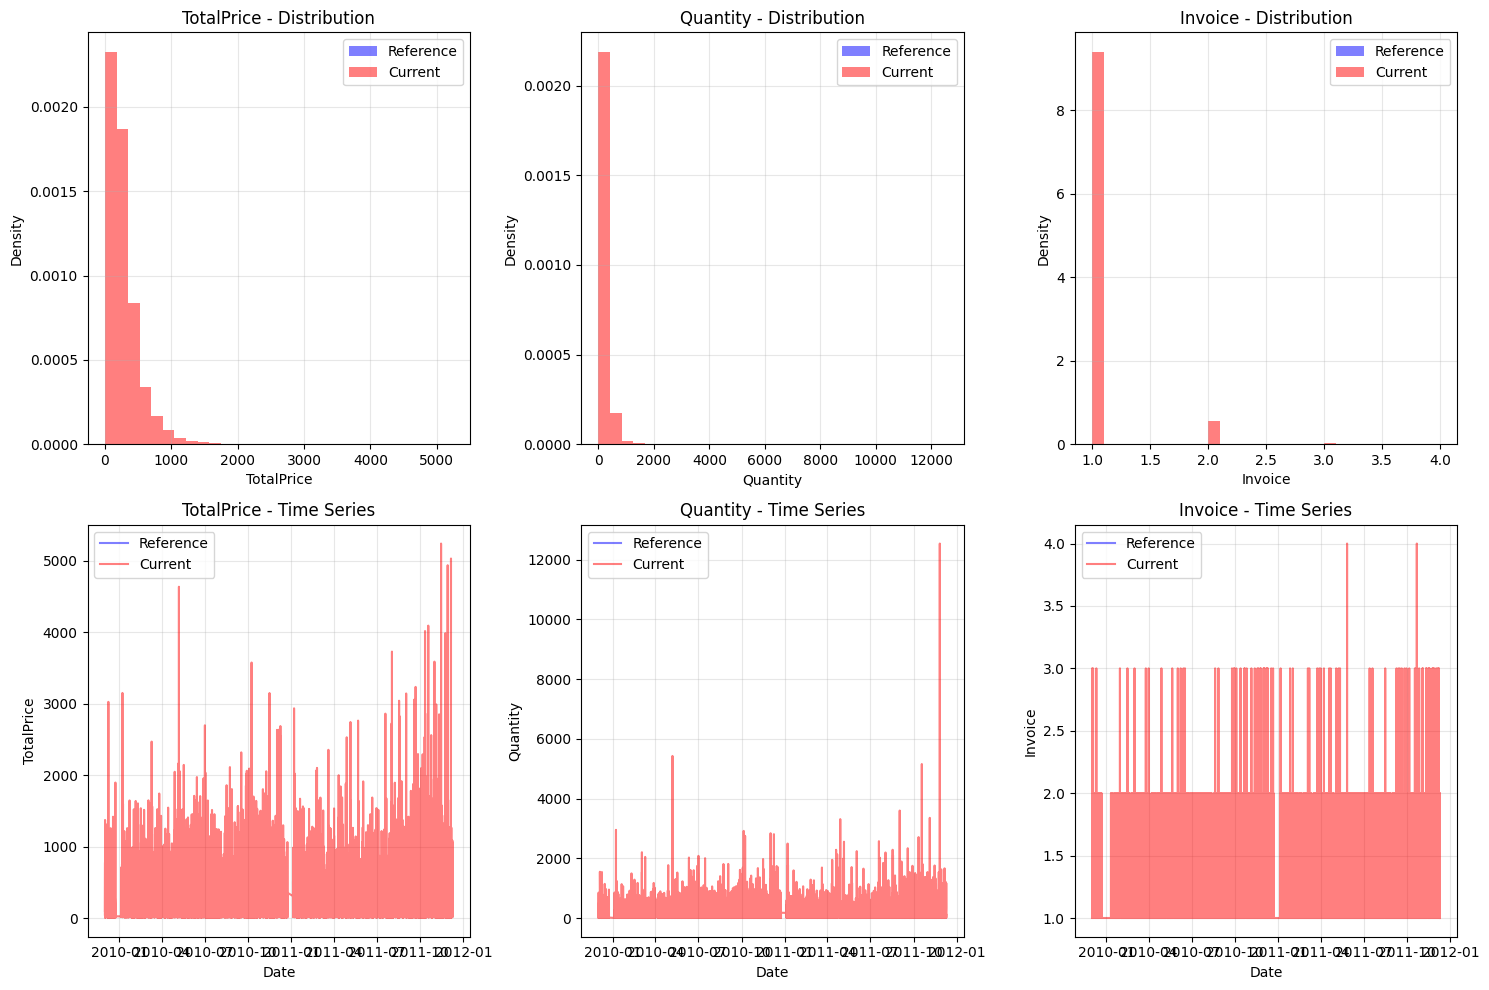


✅ Drift visualization saved to: ../data/processed/drift_visualization.png


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(columns_to_test):
    # Distribution comparison
    ax1 = axes[0, idx]
    ax1.hist(reference_daily[col].dropna(), bins=30, alpha=0.5, label='Reference', density=True, color='blue')
    ax1.hist(current_daily[col].dropna(), bins=30, alpha=0.5, label='Current', density=True, color='red')
    ax1.set_title(f'{col} - Distribution')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Time series comparison
    ax2 = axes[1, idx]
    ax2.plot(reference_daily['InvoiceDate'], reference_daily[col], alpha=0.5, label='Reference', color='blue')
    ax2.plot(current_daily['InvoiceDate'], current_daily[col], alpha=0.5, label='Current', color='red')
    ax2.set_title(f'{col} - Time Series')
    ax2.set_xlabel('Date')
    ax2.set_ylabel(col)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/drift_visualization.png', dpi=100)
plt.show()

print("\n✅ Drift visualization saved to: ../data/processed/drift_visualization.png")


In [26]:
class DriftMonitor:
    def __init__(self, reference_data, threshold=0.05):
        self.reference_data = reference_data
        self.threshold = threshold
        self.drift_history = []
        
    def check_drift(self, current_data, timestamp=None):
        """Check for drift in current data"""
        if timestamp is None:
            timestamp = datetime.now()
            
        results = {
            'timestamp': timestamp,
            'drift_detected': False,
            'columns': {}
        }
        
        for col in ['TotalPrice', 'Quantity', 'InvoiceNo']:
            if col in self.reference_data.columns and col in current_data.columns:
                ks_result = ks_drift_test(self.reference_data, current_data, col, self.threshold)
                psi_result = psi_drift_test(self.reference_data, current_data, col)
                
                results['columns'][col] = {
                    'drift_detected': ks_result['drift_detected'] or psi_result['drift_detected'],
                    'ks_p_value': ks_result['p_value'],
                    'ks_statistic': ks_result['ks_statistic'],
                    'psi_value': psi_result['psi'],
                    'severity': psi_result['severity']
                }
                
                if ks_result['drift_detected'] or psi_result['drift_detected']:
                    results['drift_detected'] = True
        
        self.drift_history.append(results)
        return results
    
    def get_drift_report(self):
        """Generate drift report DataFrame"""
        if not self.drift_history:
            return pd.DataFrame()
        
        report = pd.DataFrame([
            {
                'timestamp': r['timestamp'],
                'drift_detected': r['drift_detected'],
                'total_price_p_value': r['columns'].get('TotalPrice', {}).get('ks_p_value', 1),
                'quantity_p_value': r['columns'].get('Quantity', {}).get('ks_p_value', 1),
                'invoiceno_p_value': r['columns'].get('InvoiceNo', {}).get('ks_p_value', 1)
            }
            for r in self.drift_history
        ])
        return report

In [22]:
monitor = DriftMonitor(reference_daily, threshold=0.05)

# Test with current data
drift_check = monitor.check_drift(current_daily)

print("\n" + "="*60)
print("DRIFT MONITOR INITIALIZED")
print("="*60)
print(f"Drift detected: {drift_check['drift_detected']}")
print(f"Timestamp: {drift_check['timestamp']}")


DRIFT MONITOR INITIALIZED
Drift detected: False
Timestamp: 2026-04-19 21:22:33.718520


In [23]:
drift_config = {
    'timestamp': datetime.now().isoformat(),
    'reference_period': {
        'start': str(reference['InvoiceDate'].min()),
        'end': str(reference['InvoiceDate'].max())
    },
    'current_period': {
        'start': str(current['InvoiceDate'].min()),
        'end': str(current['InvoiceDate'].max())
    },
    'drift_threshold': 0.05,
    'monitoring_frequency': 'weekly',
    'columns_monitored': columns_to_test,
    'drift_detected': overall_drift,
    'results': {}
}

for col in columns_to_test:
    if col in drift_results:
        drift_config['results'][col] = {
            'ks_p_value': drift_results[col]['ks_test']['p_value'],
            'ks_statistic': drift_results[col]['ks_test']['ks_statistic'],
            'psi_value': drift_results[col]['psi_test']['psi'],
            'severity': drift_results[col]['psi_test']['severity'],
            'drift_detected': drift_results[col]['ks_test']['drift_detected'] or drift_results[col]['psi_test']['drift_detected']
        }

import json
with open('../data/processed/drift_config.json', 'w') as f:
    json.dump(drift_config, f, indent=2, default=str)

print("\n✅ Drift configuration saved to: ../data/processed/drift_config.json")


✅ Drift configuration saved to: ../data/processed/drift_config.json


In [24]:
print("\n" + "="*60)
print("DRIFT DETECTION SUMMARY")
print("="*60)
print(f"""
Reference Data: {len(reference_daily)} days ({reference['InvoiceDate'].min().date()} to {reference['InvoiceDate'].max().date()})
Current Data: {len(current_daily)} days ({current['InvoiceDate'].min().date()} to {current['InvoiceDate'].max().date()})

Drift Detection Methods:
- Kolmogorov-Smirnov Test (KS): Compares distributions
- Population Stability Index (PSI): Measures distribution shift

Results:
""")

for col in columns_to_test:
    if col in drift_results:
        print(f"{col}:")
        print(f"  - KS Drift: {'YES' if drift_results[col]['ks_test']['drift_detected'] else 'NO'} (p={drift_results[col]['ks_test']['p_value']:.4f})")
        print(f"  - PSI Drift: {'YES' if drift_results[col]['psi_test']['drift_detected'] else 'NO'} (PSI={drift_results[col]['psi_test']['psi']:.3f})")

print(f"\n{'='*60}")
print(f"RECOMMENDATION: {'Retrain models immediately' if overall_drift else 'Models are stable, continue monitoring'}")
print(f"{'='*60}")


DRIFT DETECTION SUMMARY

Reference Data: 0 days (NaT to NaT)
Current Data: 31376 days (2009-12-01 to 2011-12-09)

Drift Detection Methods:
- Kolmogorov-Smirnov Test (KS): Compares distributions
- Population Stability Index (PSI): Measures distribution shift

Results:

TotalPrice:
  - KS Drift: NO (p=1.0000)
  - PSI Drift: NO (PSI=0.000)
Quantity:
  - KS Drift: NO (p=1.0000)
  - PSI Drift: NO (PSI=0.000)
Invoice:
  - KS Drift: NO (p=1.0000)
  - PSI Drift: NO (PSI=0.000)

RECOMMENDATION: Models are stable, continue monitoring


In [29]:
def check_drift(new_data, reference_data, threshold=0.1):
    """
    Check if new data has drifted from reference
    """
    from scipy import stats
    
    drift_results = {}
    
    for col in ['TotalPrice', 'Quantity']:
        # Kolmogorov-Smirnov test
        ks_stat, ks_pvalue = stats.ks_2samp(
            reference_data[col].dropna(), 
            new_data[col].dropna()
        )
        
        drift_detected = ks_pvalue < threshold
        drift_results[col] = {
            'ks_statistic': ks_stat,
            'p_value': ks_pvalue,
            'drift_detected': drift_detected
        }
    
    return drift_results

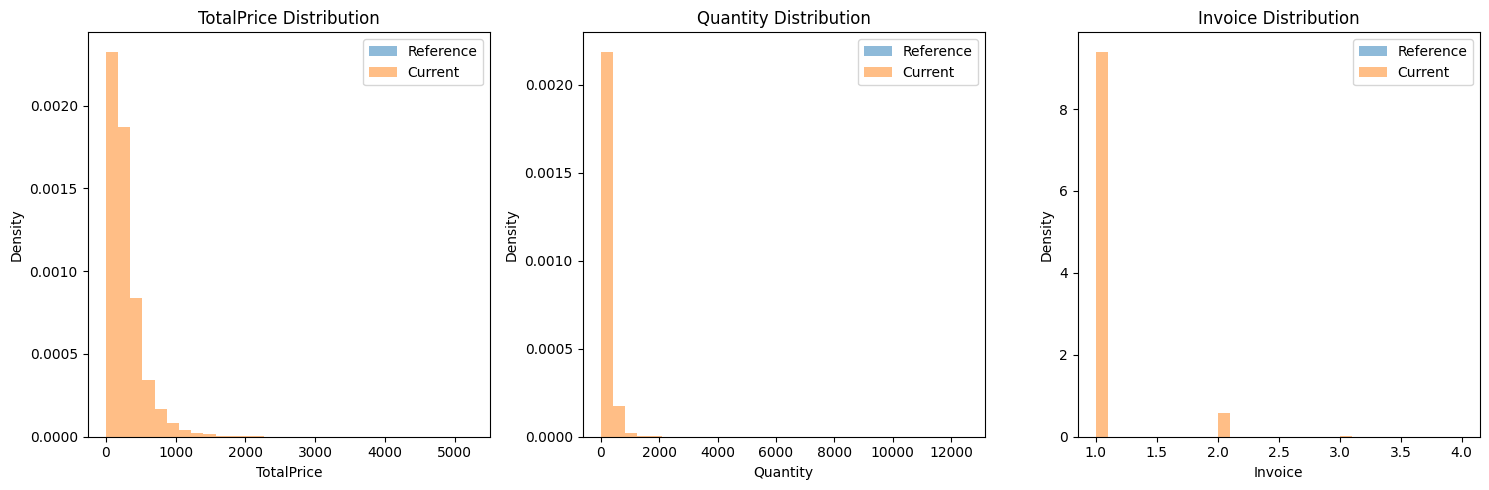


✅ Drift monitoring system ready!


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribution comparison
for idx, col in enumerate(['TotalPrice', 'Quantity', 'Invoice']):
    axes[idx].hist(reference_daily[col].dropna(), bins=30, alpha=0.5, label='Reference', density=True)
    axes[idx].hist(current_daily[col].dropna(), bins=30, alpha=0.5, label='Current', density=True)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../data/processed/drift_visualization.png')
plt.show()

print("\n✅ Drift monitoring system ready!")

In [27]:
html_report = f"""
<!DOCTYPE html>
<html>
<head>
    <title>RetailPulse - Drift Detection Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; }}
        h1 {{ color: #333; }}
        h2 {{ color: #666; margin-top: 30px; }}
        .drift-detected {{ color: red; font-weight: bold; }}
        .no-drift {{ color: green; font-weight: bold; }}
        .moderate {{ color: orange; font-weight: bold; }}
        table {{ border-collapse: collapse; width: 100%; margin-top: 20px; }}
        th, td {{ border: 1px solid #ddd; padding: 12px; text-align: left; }}
        th {{ background-color: #4CAF50; color: white; }}
        .metric {{ font-size: 24px; font-weight: bold; margin: 10px 0; }}
        .box {{ border: 1px solid #ddd; padding: 15px; margin: 10px 0; border-radius: 5px; }}
    </style>
</head>
<body>
    <h1>📊 RetailPulse - Drift Detection Report</h1>
    <p><strong>Generated:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    
    <div class="box">
        <h2>Overall Status</h2>
        <p class="metric {'drift-detected' if overall_drift else 'no-drift'}">
            {'⚠️ DRIFT DETECTED - Model Retraining Recommended' if overall_drift else '✅ No Significant Drift Detected'}
        </p>
    </div>
    
    <div class="box">
        <h2>Data Periods</h2>
        <p><strong>Reference Period:</strong> {reference['InvoiceDate'].min().date()} to {reference['InvoiceDate'].max().date()}</p>
        <p><strong>Current Period:</strong> {current['InvoiceDate'].min().date()} to {current['InvoiceDate'].max().date()}</p>
        <p><strong>Reference Days:</strong> {len(reference_daily)}</p>
        <p><strong>Current Days:</strong> {len(current_daily)}</p>
    </div>
    
    <h2>Column-wise Results</h2>
    <table>
        <tr>
            <th>Column</th>
            <th>KS Test p-value</th>
            <th>KS Drift</th>
            <th>PSI Value</th>
            <th>PSI Severity</th>
            <th>Overall Status</th>
        </tr>
"""

for col in columns_to_test:
    if col in drift_results:
        ks_drift = drift_results[col]['ks_test']['drift_detected']
        psi_drift = drift_results[col]['psi_test']['drift_detected']
        overall = ks_drift or psi_drift
        
        html_report += f"""
        <tr>
            <td><strong>{col}</strong></td>
            <td>{drift_results[col]['ks_test']['p_value']:.4f}</td>
            <td class="{'drift-detected' if ks_drift else 'no-drift'}">{'DRIFT' if ks_drift else 'Stable'}</td>
            <td>{drift_results[col]['psi_test']['psi']:.3f}</td>
            <td class="{'drift-detected' if psi_drift else 'no-drift'}">{drift_results[col]['psi_test']['severity']}</td>
            <td class="{'drift-detected' if overall else 'no-drift'}">{'DRIFT' if overall else 'Stable'}</td>
        </tr>
        """

html_report += """
    </table>
    
    <div class="box">
        <h2>Recommendations</h2>
        <ul>
"""

if overall_drift:
    html_report += """
            <li>🔴 Schedule immediate model retraining</li>
            <li>📊 Review data pipeline for changes</li>
            <li>🔄 Update reference dataset</li>
            <li>📈 Monitor model performance metrics</li>
        """
else:
    html_report += """
            <li>✅ Continue regular monitoring (weekly)</li>
            <li>📊 Current models are performing as expected</li>
            <li>📅 Schedule next drift check in 7 days</li>
            <li>🎯 No immediate action required</li>
        """

html_report += """
        </ul>
    </div>
    
    <div class="box">
        <h2>Next Steps</h2>
        <ol>
            <li>Run drift detection weekly (every Monday)</li>
            <li>Set up alerts when drift is detected</li>
            <li>Trigger automatic retraining pipeline if drift persists for 2 weeks</li>
            <li>Maintain drift history for audit purposes</li>
        </ol>
    </div>
    
    <hr>
    <p><em>RetailPulse - AI-Powered Customer Analytics Platform</em></p>
</body>
</html>
"""

with open('../data/processed/drift_report.html', 'w') as f:
    f.write(html_report)

print("\n✅ HTML drift report saved to: ../data/processed/drift_report.html")
print("\n✅ Drift detection setup complete!")


✅ HTML drift report saved to: ../data/processed/drift_report.html

✅ Drift detection setup complete!


In [28]:
drift_config = {
    'reference_period': {
        'start': str(reference['InvoiceDate'].min()),
        'end': str(reference['InvoiceDate'].max())
    },
    'current_period': {
        'start': str(current['InvoiceDate'].min()),
        'end': str(current['InvoiceDate'].max())
    },
    'drift_threshold': 0.1,
    'monitoring_frequency': 'weekly',
    'columns_monitored': ['TotalPrice', 'Quantity', 'InvoiceNo']
}

with open('../data/processed/drift_config.json', 'w') as f:
    json.dump(drift_config, f, indent=2)

print("\n✅ Drift configuration saved!")


✅ Drift configuration saved!
